# **Regularization**

Regularization is a fundamental concept in machine learning that addresses common issues encountered in predictive modeling, particularly in regression problems. These issues include model **overfitting**, **excessive variance**, and **unnecessary model complexity**.

The primary objective of regularization is to improve a model’s generalization performance by introducing **additional constraints** during training.

In practice, regularization achieves this by augmenting the original loss function with a **penalty term**.

This penalty discourages large model coefficients, thereby simplifying the model and reducing sensitivity to noise in the training data. From a statistical perspective, regularization introduces a controlled amount of bias in order to achieve a substantial reduction in variance.


## **Regularization and the Bias–Variance Tradeoff**

Regularization is closely related to the bias–variance tradeoff:

- Complex models typically exhibit low bias and high variance.
- Regularized models accept a modest increase in bias.
- This increase in bias often leads to a significant decrease in variance.

As a result, regularization is an effective mechanism for mitigating overfitting and improving out-of-sample performance.


## **Regularization as Penalized Optimization**

In standard linear regression, the model parameters are obtained by minimizing the residual sum of squares (RSS):

$$
\min_{\boldsymbol{\beta}} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2
$$

Regularization modifies this objective by adding a penalty term that depends on the magnitude of the model coefficients:

$$
\min_{\boldsymbol{\beta}} \left( \text{Loss} + \text{Penalty} \right)
$$

The penalty term is controlled by a non-negative hyperparameter ($\lambda$), which determines the strength of regularization.

In linear regression when ($lambda = 0$), the model reduces to ordinary least squares with no regularization applied.


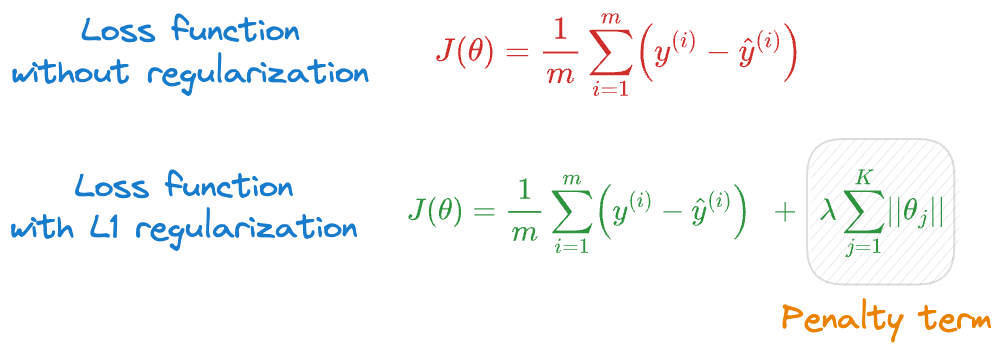

##**Types of Regularization**

This course focuses on three primary regularization techniques:

1. **L1 Regularization (LASSO Regression)**
2. **L2 Regularization (Ridge Regression)**
3. **Elastic Net Regularization**  

Each method differs in the form of the penalty imposed on the model coefficients.


## **L1 Regularization (LASSO Regression)**


L1 regularization imposes a penalty equal to the **sum of the absolute values of the regression coefficients**.

This constraint **limits the magnitude of the coefficients** and has the important property of **producing sparse models**.

As a result, some coefficients may be driven exactly to **zero**, effectively **removing the corresponding features from the model**.

This behavior makes L1 regularization particularly useful for **feature selection** and for **high-dimensional datasets** where interpretability is important.

<br>

### **Objective Function**

For linear regression with L1 regularization, the optimization problem is:

$$
\min_{\boldsymbol{\beta}}
\left(
\sum_{i=1}^{n} (y_i - \hat{y}_i)^2
\;+\;
\lambda \sum_{j=1}^{p} |\beta_j|
\right)
$$

where:
- ($\beta_j$) denotes the ($j$)-th model coefficient,
- ($\lambda \ge 0$) controls the strength of the penalty.



## **L2 Regularization (Ridge Regression)**

L2 regularization penalizes the **sum of the squared magnitudes of the model coefficients**.

Unlike L1 regularization, L2 regularization does not force coefficients to become exactly zero. Instead, it **shrinks all coefficients smoothly toward zero** by a similar proportion.

This approach reduces model variance while retaining all features in the model, making it well-suited for situations where **all** predictors are believed to contribute to the outcome.

### **Objective Function**

For linear regression with L2 regularization, the optimization problem is:

$$
\min_{\boldsymbol{\beta}}
\left(
\sum_{i=1}^{n} (y_i - \hat{y}_i)^2
\;+\;
\lambda \sum_{j=1}^{p} \beta_j^2
\right)
$$

where:
- ($\lambda \ge 0$) determines the magnitude of coefficient shrinkage.


## **Elastic Net Regularization**

Elastic Net regularization combines the properties of L1 and L2 regularization.

It introduces an additional hyperparameter, $(\alpha)$, which controls the relative contribution of the L1 and L2 penalties.

This approach is particularly useful when dealing with correlated predictors, as it balances sparsity and coefficient stability.

### **Objective Function**

The Elastic Net optimization problem is defined as:

$$
\min_{\boldsymbol{\beta}}
\left(
\sum_{i=1}^{n} (y_i - \hat{y}_i)^2
\;+\;
\lambda \left[
\alpha \sum_{j=1}^{p} |\beta_j|
\;+\;
\frac{1 - \alpha}{2} \sum_{j=1}^{p} \beta_j^2
\right]
\right)
$$

where:
- $(\lambda \ge 0)$ controls the overall strength of regularization,
- $(\alpha \in [0,1])$ controls the balance between L1 and L2 penalties:
  - $(\alpha = 1)$: LASSO regression,
  - $(\alpha = 0)$: Ridge regression.


## **Hyperparameter Tuning**

Regularized models introduce additional hyperparameters, such as $(\lambda)$ and $(\alpha)$, that must be selected carefully. These parameters are not learned directly from the training data through optimization. Instead, they are typically chosen using techniques such as cross-validation.

The tuning process involves evaluating model performance across a range of candidate hyperparameter values and selecting the configuration that yields the best validation performance.


# **Regularization in sk-learn**

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
df = pd.read_csv("Advertising.csv")
X = df.drop('sales',axis=1)
y = df['sales']

In [ ]:
from sklearn.preprocessing import PolynomialFeatures
polynomial_converter = PolynomialFeatures(degree=3,include_bias=False)
poly_features = polynomial_converter.fit_transform(X)

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(poly_features, y, test_size=0.3, random_state=101)


## **Importance of Scaling in Regularization**

Feature scaling is **critical** for regularized models because:

- Regularization penalties depend directly on coefficient **magnitudes**
- Features with larger numeric ranges can **dominate the penalty term**
- L1 and L2 penalties assume features are on **comparable scales**

Without scaling, regularization results can be misleading or unstable.

In [ ]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaler.fit(X_train)
X_train = scaler.transform(X_train)
X_test = scaler.transform(X_test)

## **Ridge Regression**

### **Notational Convention in scikit-learn: Alpha vs. Lambda**

In the mathematical formulation of ridge regression, the regularization strength is typically denoted by the parameter $(\lambda)$. However, **scikit-learn consistently refers to this parameter as `alpha`** across many model classes.

This design choice enforces a uniform API and reduces the need to remember different parameter names for different models. When using ridge regression in scikit-learn:  $
\alpha \equiv \lambda
$

It is therefore important to mentally map `alpha` in code to the regularization strength discussed in theory.

<br>



Ridge regression is implemented via the `Ridge` class from `sklearn.linear_model`.

A ridge model is created by specifying the `alpha` parameter:

- Larger `alpha` values → stronger regularization
- Smaller `alpha` values → weaker regularization
- `alpha = 0` → equivalent to ordinary least squares (not recommended in practice)

In [ ]:
from sklearn.linear_model import Ridge
ridge_model = Ridge(alpha=10)
ridge_model.fit(X_train,y_train)

Ridge(alpha=10)

In [ ]:
test_predictions = ridge_model.predict(X_test)

In [ ]:
from sklearn.metrics import mean_absolute_error,mean_squared_error
MAE = mean_absolute_error(y_test,test_predictions)
MAE

0.5774404204714163

In [ ]:
MSE = mean_squared_error(y_test,test_predictions)
MSE

0.8003783071528352

In [ ]:
RMSE = np.sqrt(MSE)
RMSE

np.float64(0.894638646131965)

How did it perform on the training set? (This will be used later on for comparison)

In [ ]:
# Training Set Performance
train_predictions = ridge_model.predict(X_train)
MAE = mean_absolute_error(y_train,train_predictions)
MAE

0.5288348183025309

### **Choosing an alpha value with Cross-Validation**

The choice of `alpha = 10` is arbitrary and not guaranteed to be optimal. The regularization strength must be **tuned** to balance bias and variance appropriately.

This tuning is performed using **cross-validation**, which:
- Evaluates multiple values of `alpha`
- Uses only the training data
- Selects the value that optimizes a chosen scoring metric

The test set remains untouched during this process and serves as a final holdout for evaluation.

<br>

scikit-learn provides a specialized class, `RidgeCV`, which automates:

- Cross-validation
- Hyperparameter selection
- Model refitting using the optimal `alpha`

#### **Key Differences from `Ridge`**

- `alpha` is replaced by `alphas`, a list or array of candidate values
- Cross-validation is performed internally
- The best-performing `alpha` is stored after fitting

<br>



### **Scoring Metrics in scikit-learn**

#### **Uniform Scoring Convention**

All scoring metrics in scikit-learn follow the convention:

> **Higher scores indicate better performance**

This presents a challenge for error-based metrics (e.g., MAE, MSE), where lower values are better.

#### **Solution: Negative Error Metrics**

To maintain uniformity, scikit-learn defines regression error scorers as **negative values**, such as:

- `neg_mean_absolute_error`
- `neg_mean_squared_error`

A higher (less negative) value corresponds to a lower actual error.

In [ ]:
from sklearn.linear_model import RidgeCV

# Choosing a scoring: https://scikit-learn.org/stable/modules/model_evaluation.html
# Negative RMSE so all metrics follow convention "Higher is better"

# See all options: sklearn.metrics.SCORERS.keys()
ridge_cv_model = RidgeCV(alphas=(0.1, 1.0, 10.0),scoring='neg_mean_absolute_error')

In [ ]:
# The more alpha options you pass, the longer this will take.
# Fortunately our data set is still pretty small
ridge_cv_model.fit(X_train,y_train)

RidgeCV(scoring='neg_mean_absolute_error')

In [ ]:
ridge_cv_model.alpha_

np.float64(0.1)

In [ ]:
test_predictions = ridge_cv_model.predict(X_test)

In [ ]:
MAE = mean_absolute_error(y_test,test_predictions)
MAE

0.427377488434534

In [ ]:
MSE = mean_squared_error(y_test,test_predictions)
MSE

0.3820129881525864

In [ ]:
RMSE = np.sqrt(MSE)
RMSE

np.float64(0.6180719926938822)

In [ ]:
# Training Set Performance
# Training Set Performance
train_predictions = ridge_cv_model.predict(X_train)
MAE = mean_absolute_error(y_train,train_predictions)
MAE

0.30941321056539456

In [ ]:
ridge_cv_model.coef_

array([ 5.40769392,  0.5885865 ,  0.40390395, -6.18263924,  4.59607939,
       -1.18789654, -1.15200458,  0.57837796, -0.1261586 ,  2.5569777 ,
       -1.38900471,  0.86059434,  0.72219553, -0.26129256,  0.17870787,
        0.44353612, -0.21362436, -0.04622473, -0.06441449])

In [ ]:
ridge_cv_model.coef_.shape

(19,)

In [ ]:
poly_features.shape

(200, 19)

In [ ]:
# Assuming 'model' is a fitted RidgeCV instance
coefficients = ridge_cv_model.coef_

# If you want to pair coefficients with feature names (a common practice):
feature_names = poly_features[0] # Assuming X_train is a pandas DataFrame
for feature, coef in zip(feature_names, coefficients):
    print(f"{feature}: {coef}")


230.1: 5.4076939239242865
37.8: 0.5885865048279313
69.2: 0.40390394512590877
52946.009999999995: -6.18263923518122
8697.779999999999: 4.596079385593748
15922.92: -1.187896536229771
1428.8399999999997: -1.1520045828395438
2615.7599999999998: 0.5783779624333718
4788.64: -0.12615859620528713
12182876.900999999: 2.556977698065391
2001359.1779999996: -1.3890047094170646
3663863.892: 0.8605943403802017
328776.0839999999: 0.7221955273312535
601886.3759999999: -0.26129256305062176
1101866.064: 0.17870786625202273
54010.15199999999: 0.4435361202822077
98875.72799999999: -0.21362435562777526
181010.592: -0.04622472634398922
331373.88800000004: -0.06441448703160169


<br><br>

## **Train | Test Split Procedure**

0. Clean and adjust data as necessary for X and y
1. Split Data in Train/Test for both X and y
2. Fit/Train Scaler on Training X Data
3. Scale X Test Data
4. Create Model
5. Fit/Train Model on X Train Data
6. Evaluate Model on X Test Data (by creating predictions and comparing to Y_test)
7. Adjust Parameters as Necessary and repeat steps 5 and 6

In [ ]:
## CREATE X and y
X = df.drop('sales',axis=1)
y = df['sales']

# TRAIN TEST SPLIT
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=101)

# SCALE DATA
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaler.fit(X_train)
X_train = scaler.transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
from sklearn.linear_model import Ridge

# Poor Alpha Choice on purpose!
model = Ridge(alpha=100)
model.fit(X_train,y_train)

Ridge(alpha=100)

In [ ]:
y_pred = model.predict(X_test)

In [ ]:
from sklearn.metrics import mean_squared_error
mean_squared_error(y_test,y_pred)

7.34177578903413

**Adjust Parameters and Re-evaluate**

In [ ]:
model = Ridge(alpha=1)
model.fit(X_train,y_train)

Ridge(alpha=1)

In [ ]:
y_pred = model.predict(X_test)

In [ ]:
mean_squared_error(y_test,y_pred)

2.319021579428752

Much better! We could repeat this until satisfied with performance metrics. (We previously showed RidgeCV can do this for us, but the purpose of this lecture is to generalize the CV process for any model).

## **Train | Validation | Test Split Procedure**



This is often also called a "hold-out" set, since you should not adjust parameters based on the final test set, but instead use it *only* for reporting final expected performance.

0. Clean and adjust data as necessary for X and y
1. Split Data in Train/Validation/Test for both X and y
2. Fit/Train Scaler on Training X Data
3. Scale X Eval Data
4. Create Model
5. Fit/Train Model on X Train Data
6. Evaluate Model on X Evaluation Data (by creating predictions and comparing to Y_eval)
7. Adjust Parameters as Necessary and repeat steps 5 and 6
8. Get final metrics on Test set (not allowed to go back and adjust after this!)

In [ ]:
## CREATE X and y
X = df.drop('sales',axis=1)
y = df['sales']

In [ ]:
######################################################################
#### SPLIT TWICE! Here we create TRAIN | VALIDATION | TEST  #########
####################################################################
from sklearn.model_selection import train_test_split

# 70% of data is training data, set aside other 30%
X_train, X_OTHER, y_train, y_OTHER = train_test_split(X, y, test_size=0.3, random_state=101)

# Remaining 30% is split into evaluation and test sets
# Each is 15% of the original data size
X_eval, X_test, y_eval, y_test = train_test_split(X_OTHER, y_OTHER, test_size=0.5, random_state=101)

In [ ]:
# SCALE DATA
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaler.fit(X_train)
X_train = scaler.transform(X_train)
X_eval = scaler.transform(X_eval)
X_test = scaler.transform(X_test)

In [ ]:
from sklearn.linear_model import Ridge
# Poor Alpha Choice on purpose!
model = Ridge(alpha=100)

In [ ]:
model.fit(X_train,y_train)

Ridge(alpha=100)

In [ ]:
y_eval_pred = model.predict(X_eval)

In [ ]:
from sklearn.metrics import mean_squared_error
mean_squared_error(y_eval,y_eval_pred)

7.320101458823871

**Adjust Parameters and Re-evaluate**

In [ ]:
model = Ridge(alpha=1)
model.fit(X_train,y_train)

Ridge(alpha=1)

In [ ]:
y_eval_pred = model.predict(X_eval)

In [ ]:
mean_squared_error(y_eval,y_eval_pred)

2.383783075056986

**Final Evaluation (Can no longer edit parameters after this!)**

In [ ]:
y_final_test_pred = model.predict(X_test)

In [ ]:
mean_squared_error(y_test,y_final_test_pred)

2.2542600838005176

## **Cross Validation Score:** `cross_val_score`

In [ ]:
## CREATE X and y
X = df.drop('sales',axis=1)
y = df['sales']

# TRAIN TEST SPLIT
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=101)

# SCALE DATA
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaler.fit(X_train)
X_train = scaler.transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
model = Ridge(alpha=100)

In [ ]:
from sklearn.model_selection import cross_val_score

# SCORING OPTIONS:
# https://scikit-learn.org/stable/modules/model_evaluation.html
scores = cross_val_score(model,X_train,y_train,
                         scoring='neg_mean_squared_error',cv=5)

scores

array([ -9.32552967,  -4.9449624 , -11.39665242,  -7.0242106 ,
        -8.38562723])

In [ ]:
# Average of the MSE scores (we set back to positive)
abs(scores.mean())

np.float64(8.215396464543607)

**Adjust Parameters and Re-evaluate**

In [ ]:
model = Ridge(alpha=1)

In [ ]:
# SCORING OPTIONS:
# https://scikit-learn.org/stable/modules/model_evaluation.html
scores = cross_val_score(model,X_train,y_train,
                         scoring='neg_mean_squared_error',cv=5)

In [ ]:
# Average of the MSE scores (we set back to positive)
abs(scores.mean())

np.float64(3.344839296530695)

**Final Evaluation (Can no longer edit parameters after this!)**

In [ ]:
# Need to fit the model first!
model.fit(X_train,y_train)

Ridge(alpha=1)

In [ ]:
y_final_test_pred = model.predict(X_test)

In [ ]:
mean_squared_error(y_test,y_final_test_pred)

2.319021579428752

## **Cross Validation with cross_validate**

The cross_validate function differs from cross_val_score in two ways:

It allows specifying multiple metrics for evaluation.

It returns a dict containing fit-times, score-times (and optionally training scores as well as fitted estimators) in addition to the test score.

For single metric evaluation, where the scoring parameter is a string, callable or None, the keys will be:
        
        - ['test_score', 'fit_time', 'score_time']

And for multiple metric evaluation, the return value is a dict with the following keys:

    ['test_<scorer1_name>', 'test_<scorer2_name>', 'test_<scorer...>', 'fit_time', 'score_time']

return_train_score is set to False by default to save computation time. To evaluate the scores on the training set as well you need to be set to True.

In [ ]:
## CREATE X and y
X = df.drop('sales',axis=1)
y = df['sales']

# TRAIN TEST SPLIT
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=101)

# SCALE DATA
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaler.fit(X_train)
X_train = scaler.transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
model = Ridge(alpha=100)

In [ ]:
from sklearn.model_selection import cross_validate

# SCORING OPTIONS:
# https://scikit-learn.org/stable/modules/model_evaluation.html
scores = cross_validate(model,X_train,y_train,
                         scoring=['neg_mean_absolute_error','neg_mean_squared_error','max_error'],cv=5)

In [ ]:
scores

{'fit_time': array([0.00236392, 0.00161242, 0.00145555, 0.00130606, 0.00167584]),
 'score_time': array([0.00282574, 0.00183201, 0.00171995, 0.00162172, 0.00264478]),
 'test_neg_mean_absolute_error': array([-2.31243044, -1.74653361, -2.56211701, -2.01873159, -2.27951906]),
 'test_neg_mean_squared_error': array([ -9.32552967,  -4.9449624 , -11.39665242,  -7.0242106 ,
         -8.38562723]),
 'test_max_error': array([ -6.44988486,  -5.58926073, -10.33914027,  -6.61950405,
         -7.75578515])}

In [ ]:
pd.DataFrame(scores)

,fit_time,score_time,test_neg_mean_absolute_error,test_neg_mean_squared_error,test_max_error
0,0.002364,0.002826,-2.312430,-9.325530,-6.449885
1,0.001612,0.001832,-1.746534,-4.944962,-5.589261
2,0.001456,0.001720,-2.562117,-11.396652,-10.339140
3,0.001306,0.001622,-2.018732,-7.024211,-6.619504
4,0.001676,0.002645,-2.279519,-8.385627,-7.755785


In [ ]:
pd.DataFrame(scores).mean()

,0
fit_time,0.001683
score_time,0.002129
test_neg_mean_absolute_error,-2.183866
test_neg_mean_squared_error,-8.215396
test_max_error,-7.350715


**Adjust model based on metrics**

In [ ]:
model = Ridge(alpha=1)

In [ ]:
# SCORING OPTIONS:
# https://scikit-learn.org/stable/modules/model_evaluation.html
scores = cross_validate(model,X_train,y_train,
                         scoring=['neg_mean_absolute_error','neg_mean_squared_error','max_error'],cv=5)

In [ ]:
pd.DataFrame(scores).mean()

,0
fit_time,0.002847
score_time,0.002620
test_neg_mean_absolute_error,-1.319685
test_neg_mean_squared_error,-3.344839
test_max_error,-5.161145


**Final Evaluation (Can no longer edit parameters after this!)**

In [ ]:
# Need to fit the model first!
model.fit(X_train,y_train)

Ridge(alpha=1)

In [ ]:
y_final_test_pred = model.predict(X_test)

In [ ]:
mean_squared_error(y_test,y_final_test_pred)

2.319021579428752

<br><br>

# Grid Search

We can search through a variety of combinations of hyperparameters with a grid search. While many linear models are quite simple and even come with their own specialized versions that do a search for you, this method of a grid search will can be applied to *any* model from sklearn, and we will need to use it later on for more complex models, such as Support Vector Machines.

In [ ]:
## CREATE X and y
X = df.drop('sales',axis=1)
y = df['sales']

# TRAIN TEST SPLIT
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=101)

# SCALE DATA
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaler.fit(X_train)
X_train = scaler.transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
from sklearn.linear_model import ElasticNet

base_elastic_model = ElasticNet()

A search consists of:

* an estimator (regressor or classifier such as sklearn.svm.SVC());
* a parameter space;
* a method for searching or sampling candidates;
* a cross-validation scheme
* a score function.

In [ ]:
param_grid = {'alpha':[0.1,1,5,10,50,100],
              'l1_ratio':[.1, .5, .7, .9, .95, .99, 1]}

In [ ]:
from sklearn.model_selection import GridSearchCV

# verbose number a personal preference
grid_model = GridSearchCV(estimator=base_elastic_model,
                          param_grid=param_grid,
                          scoring='neg_mean_squared_error',
                          cv=5,
                          verbose=2)

In [ ]:
grid_model.fit(X_train,y_train)

Fitting 5 folds for each of 42 candidates, totalling 210 fits
[CV] END ............................alpha=0.1, l1_ratio=0.1; total time=   0.0s
[CV] END ............................alpha=0.1, l1_ratio=0.1; total time=   0.0s
[CV] END ............................alpha=0.1, l1_ratio=0.1; total time=   0.0s
[CV] END ............................alpha=0.1, l1_ratio=0.1; total time=   0.0s
[CV] END ............................alpha=0.1, l1_ratio=0.1; total time=   0.0s
[CV] END ............................alpha=0.1, l1_ratio=0.5; total time=   0.0s
[CV] END ............................alpha=0.1, l1_ratio=0.5; total time=   0.0s
[CV] END ............................alpha=0.1, l1_ratio=0.5; total time=   0.0s
[CV] END ............................alpha=0.1, l1_ratio=0.5; total time=   0.0s
[CV] END ............................alpha=0.1, l1_ratio=0.5; total time=   0.0s
[CV] END ............................alpha=0.1, l1_ratio=0.7; total time=   0.0s
[CV] END ............................alpha=0.1,

GridSearchCV(cv=5, estimator=ElasticNet(),
             param_grid={'alpha': [0.1, 1, 5, 10, 50, 100],
                         'l1_ratio': [0.1, 0.5, 0.7, 0.9, 0.95, 0.99, 1]},
             scoring='neg_mean_squared_error', verbose=2)

In [ ]:
grid_model.best_estimator_

ElasticNet(alpha=0.1, l1_ratio=1)

In [ ]:
grid_model.best_params_

{'alpha': 0.1, 'l1_ratio': 1}

### **Using Best Model From Grid Search**

In [ ]:
y_pred = grid_model.predict(X_test)

In [ ]:
from sklearn.metrics import mean_squared_error
mean_squared_error(y_test,y_pred)

2.387342642087474